In [ ]:
# importing the libraries for the linear regression
import numpy as np
import pandas as pd
#importing the train_test_split
from sklearn.model_selection import train_test_split
#importing the accuracy score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
#importing the seaborne and matpotlib
import seaborn as sns
import matplotlib.pyplot as plt
#importing the standard
from sklearn.preprocessing import StandardScaler


In [ ]:
data = pd.read_csv("/content/resume_dataset_with_salary.csv")
from sklearn.linear_model import LinearRegression


In [ ]:
# converting the education into numerical
data["education"] = data["education"].astype("string").str.strip().str.title()
edu_map={
    "PhD":1,
    "Master":2,
    "Bachelor":3
}

data["education"] = data["education"].map(edu_map)
data["education"] = data["education"].fillna(0).astype(int)

In [ ]:
X = data[["experience","education"]]

Y = data["salary"]


scaler= StandardScaler()

scaler.fit(X)
standardized_data = scaler.transform(X)
X = standardized_data

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=2)


model = LinearRegression()
model.fit(X_train,Y_train)

y_predictions = model.predict(X_train)

'''using the r2_score because the accuracy_score is not working on this dataset and will return zero
example -
          y_true = [0, 1, 1, 0, 1]
          y_pred = [0, 1, 0, 0, 1]
          accuracy = 3 / 5 = 0.6

'''

# predicting the accuracy of the trained data
training_data_accuracy = r2_score(Y_train,y_predictions)
print("R-squared on training data is : ",training_data_accuracy*100)

# predicting the data on the test data
y_prediction = model.predict(X_test)
test_data_accuracy = r2_score(Y_test,y_prediction)
print("R-squared on the testing data is: ", test_data_accuracy*100)

# predicting the Mean Absolute Error (MAE)
MAE_data_accuracy = mean_absolute_error(Y_train,y_predictions)
print("Mean Absolute Error on training data is : ",round(MAE_data_accuracy))

#predicting the Mean Squared Error (MSA)

# MSE_data_accuracy = mean_squared_error(Y_train,y_predictions)
# print("Mean Squared Error on training data is : ",round(MSE_data_accuracy))

# predicting the Root Mean Squared Error (RMSE)
RMSE_data_accuracy = root_mean_squared_error(Y_train,y_predictions)
print("Root Mean Squared Error on training data is : ",round(RMSE_data_accuracy))



R-squared on training data is :  92.75366588865577
R-squared on the testing data is:  91.32764683768704
Mean Absolute Error on training data is :  5503
Root Mean Squared Error on training data is :  6600


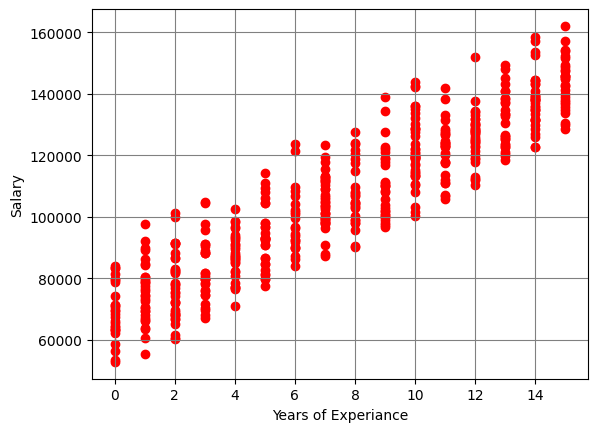

In [ ]:
experience = data["experience"]
salary = data["salary"]
plt.scatter(experience,salary,color="red")
# plt.plot(X_train,y_predictions,color="blue")
plt.xlabel("Years of Experiance")
plt.ylabel("Salary")
plt.grid(color="gray")
plt.show()

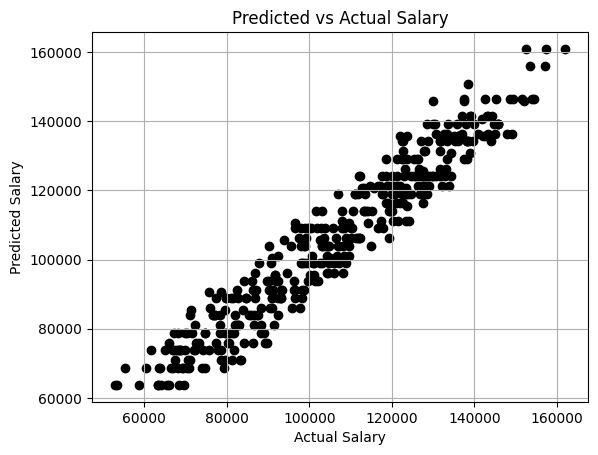

In [ ]:
plt.scatter(Y_train, y_predictions, color="black")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Predicted vs Actual Salary")
plt.grid(True)
plt.show()

In [ ]:
#predictive system
experiance = int(input("Enter the years of Expericance: "))

# Here 1 represent i am a PhD student
# " u can select from 1 to 3"
education = 1
user_input = np.array([experiance, education]).reshape(1, -1)

x_transform = scaler.transform(user_input)

prediction = model.predict(x_transform)


print(f"\033[32mThe Predicted Salary is: {prediction[0]:.0f}\033[0m")

Enter the years of Expericance: 1
[83243.41098369]
The Predicted Salary is: 83243


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
